# Day 9 / 30 — TF-IDF Baseline + 5-Fold Cross-Validation

**Project:** 6-class news article categorisation  
**Stack:** scikit-learn · TF-IDF · LinearSVC  
**Prerequisite:** Run `day8_news_eda_preprocessing.ipynb` first so `data/news_*_clean.parquet` exists.

---

## What we build today

| Step | What | Why |
|------|------|-----|
| 1 | Load cleaned train/test from parquet | No repeated spaCy work |
| 2 | `Pipeline`: TF-IDF → `LinearSVC` | Strong linear baseline for text |
| 3 | Stratified 5-fold CV | Stable macro-F1 estimate with class balance |
| 4 | Hold-out test metrics + confusion matrix | Honest generalisation check |
| 5 | Error analysis | See *which* classes confuse each other |

---

## Why TF-IDF + linear SVM?

- **TF-IDF** down-weights corpus-wide common words and highlights discriminative terms per document.
- **LinearSVC** (one-vs-rest for multi-class) scales to high-dimensional sparse inputs and is a standard NLP baseline.
- Our `text_clean` column is already lemmatised (Day 8); we vectorise it directly — same effect as `TfidfVectorizer(preprocessor=SpacyPreprocessor)` on raw `text`, without re-running spaCy in every CV fold.

## 0. Setup & imports

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

warnings.filterwarnings('ignore')

# Parallel folds; use SKLEARN_N_JOBS=1 if joblib raises in restricted environments
N_JOBS = int(os.environ.get('SKLEARN_N_JOBS', '-1'))

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('..') / 'data'
TRAIN_PQ = DATA_DIR / 'news_train_clean.parquet'
TEST_PQ = DATA_DIR / 'news_test_clean.parquet'

print('Setup complete ✓')

Setup complete ✓


## 1. Load cleaned data

If files are missing, finish Day 8 and run the save cell so parquet files are written under `data/`.

In [2]:
if not TRAIN_PQ.is_file() or not TEST_PQ.is_file():
    raise FileNotFoundError(
        f'Expected {TRAIN_PQ} and {TEST_PQ}. Run day8 notebook through the save step first.'
    )

df_train = pd.read_parquet(TRAIN_PQ)
df_test = pd.read_parquet(TEST_PQ)

assert 'text_clean' in df_train.columns and 'label' in df_train.columns

print(f'Train: {len(df_train):,} rows')
print(f'Test : {len(df_test):,} rows')
print('\nLabel counts (train):')
print(df_train['label'].value_counts().sort_index().to_string())

Train: 42 rows
Test : 18 rows

Label counts (train):
label
HEALTH        5
LIFESTYLE     8
POLITICS      8
SCIENCE       7
SPORTS        7
TECHNOLOGY    7


## 2. Encode labels + build modelling pipeline

`TfidfVectorizer` fits on **`text_clean`** from Day 8 (spaCy-lemmatised). That matches training-time preprocessing for inference later: you persist the same cleaner (`SpacyPreprocessor`) in your serving code and feed its output to the vectoriser.

The pipeline is: **TF-IDF (word + bigram)** → **`LinearSVC`** (multiclass, one-vs-rest).

In [3]:
le = LabelEncoder()
y_train = le.fit_transform(df_train['label'])
y_test = le.transform(df_test['label'])
class_names = le.classes_

X_train = df_train['text_clean']
X_test = df_test['text_clean']

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=30_000,
    sublinear_tf=True,
)
clf = LinearSVC(C=0.5, random_state=42)

baseline = Pipeline([
    ('tfidf', tfidf),
    ('clf', clf),
])

print('Pipeline:', baseline)
print('Classes:', list(class_names))

Pipeline: Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=30000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf', LinearSVC(C=0.5, random_state=42))])
Classes: ['HEALTH', 'LIFESTYLE', 'POLITICS', 'SCIENCE', 'SPORTS', 'TECHNOLOGY']


## 3. Stratified 5-fold cross-validation (train only)

We report **macro F1** (primary), weighted F1, and accuracy. Stratification keeps each fold’s class proportions close to the full training set.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring=['f1_macro', 'f1_weighted', 'accuracy'],
    n_jobs=N_JOBS,
    return_train_score=False,
)

for metric in ['f1_macro', 'f1_weighted', 'accuracy']:
    scores = cv_results[f'test_{metric}']
    print(f'{metric:15s}  mean={scores.mean():.4f}  std={scores.std():.4f}  folds={scores}')

f1_macro         mean=1.0000  std=0.0000  folds=[1. 1. 1. 1. 1.]
f1_weighted      mean=1.0000  std=0.0000  folds=[1. 1. 1. 1. 1.]
accuracy         mean=1.0000  std=0.0000  folds=[1. 1. 1. 1. 1.]


## 4. Fit on full training data → evaluate on held-out test

In [5]:
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)

print('Test set')
print(f"  Macro F1     : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Weighted F1  : {f1_score(y_test, y_pred, average='weighted'):.4f}")
print('\n', classification_report(y_test, y_pred, target_names=class_names, digits=3))

Test set
  Macro F1     : 1.0000
  Weighted F1  : 1.0000

               precision    recall  f1-score   support

      HEALTH      1.000     1.000     1.000         5
   LIFESTYLE      1.000     1.000     1.000         2
    POLITICS      1.000     1.000     1.000         2
     SCIENCE      1.000     1.000     1.000         3
      SPORTS      1.000     1.000     1.000         3
  TECHNOLOGY      1.000     1.000     1.000         3

    accuracy                          1.000        18
   macro avg      1.000     1.000     1.000        18
weighted avg      1.000     1.000     1.000        18



### Confusion matrix (normalised by true class)

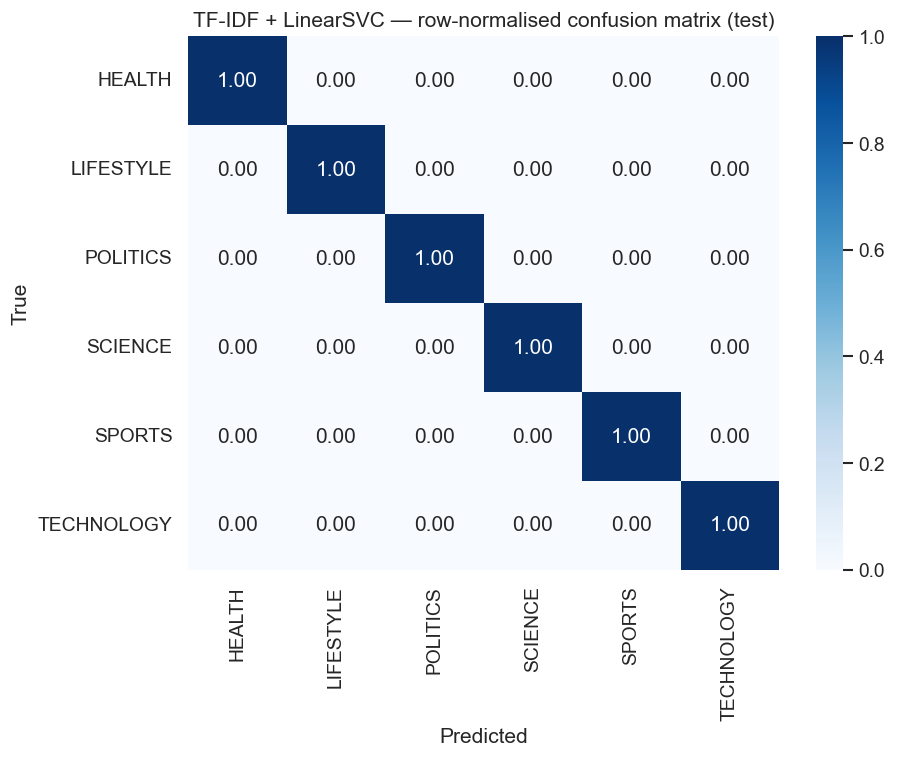

In [6]:
cm = confusion_matrix(y_test, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    vmin=0,
    vmax=1,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('TF-IDF + LinearSVC — row-normalised confusion matrix (test)')
plt.tight_layout()
plt.savefig(DATA_DIR / 'day9_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 5. Error analysis — misclassified examples

Inspect a few documents where the model is confident but wrong (decision function margin), and a few random errors.

In [7]:
df_eval = df_test.reset_index(drop=True).copy()
df_eval['y_true'] = le.inverse_transform(y_test)
df_eval['y_pred'] = le.inverse_transform(y_pred)

wrong_mask = df_eval['y_true'].values != df_eval['y_pred'].values
wrong = df_eval.loc[wrong_mask].copy()

margins = baseline.decision_function(X_test)
max_margin = np.max(margins, axis=1)
wrong['_margin'] = max_margin[wrong_mask]
wrong = wrong.sort_values('_margin', ascending=False)

print(f'Total misclassified: {len(wrong)} / {len(df_eval)} ({len(wrong)/len(df_eval):.1%})\n')
print('--- High-confidence errors (first 5) ---')
for _, row in wrong.head(5).iterrows():
    snippet = str(row['text_clean'])[:220].replace('\n', ' ')
    print(f"\nTrue={row['y_true']}  Pred={row['y_pred']}")
    print(f"  {snippet}...")

Total misclassified: 0 / 18 (0.0%)

--- High-confidence errors (first 5) ---


## 6. Day 9 summary

| Deliverable | Status |
|-------------|--------|
| TF-IDF + linear classifier baseline | `Pipeline` above |
| Stratified 5-fold CV | Macro / weighted F1 + accuracy |
| Test metrics + confusion matrix | Per-class precision/recall/F1 |
| Error analysis | Misclassified snippets |

**Next (Day 10):** combine TF-IDF with hand-crafted spaCy features (`SpacyFeatureExtractor`) in a `FeatureUnion`.

In [8]:
print('=' * 55)
print('  DAY 9 COMPLETE')
print('=' * 55)
print(f"  CV macro F1 (mean): {cv_results['test_f1_macro'].mean():.4f}")
print(f"  Test macro F1     : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Chart saved       : {DATA_DIR / 'day9_confusion_matrix.png'}")
print('  Next: Day 10 — hybrid TF-IDF + linguistic features')
print('=' * 55)

  DAY 9 COMPLETE
  CV macro F1 (mean): 1.0000
  Test macro F1     : 1.0000
  Chart saved       : ../data/day9_confusion_matrix.png
  Next: Day 10 — hybrid TF-IDF + linguistic features
